In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv('wine_data.csv',header=None, usecols=[0,1,2])
df.columns = ['Class label','Alcohol', 'Malic Acid']

In [14]:
df.sample(5)

,Class label,Alcohol,Malic Acid
149,3,13.08,3.90
154,3,12.58,1.29
94,2,11.62,1.99
76,2,13.03,0.90
68,2,13.34,0.94


<Axes: xlabel='Alcohol', ylabel='Density'>

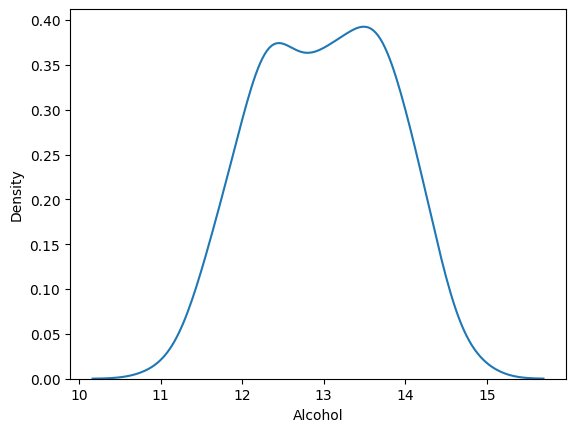

In [15]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic Acid', ylabel='Density'>

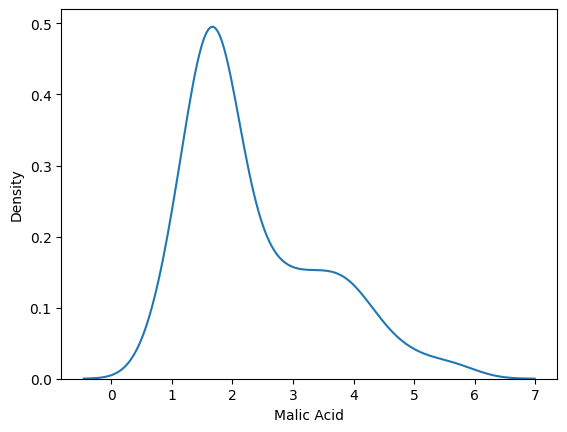

In [16]:
sns.kdeplot(df['Malic Acid'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

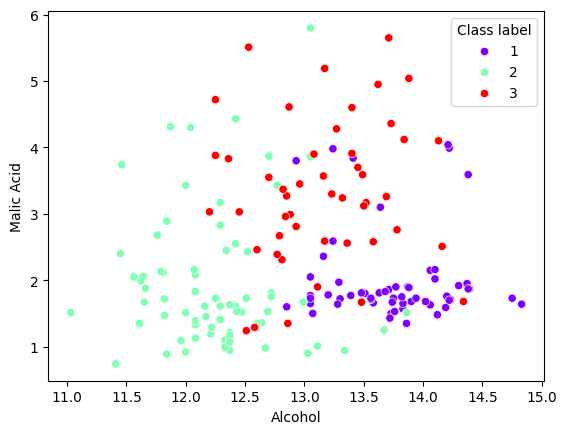

In [20]:
sns.scatterplot(df, x='Alcohol', y='Malic Acid', hue='Class label', palette='rainbow')

## Train Split Test

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    df.drop('Class label', axis=1), df['Class label'],
    test_size=0.3, random_state=0
)

X_train.shape, X_test.shape


((124, 2), (54, 2))

In [26]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [29]:
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


In [30]:
np.round(X_train.describe(),1)

,Alcohol,Malic Acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


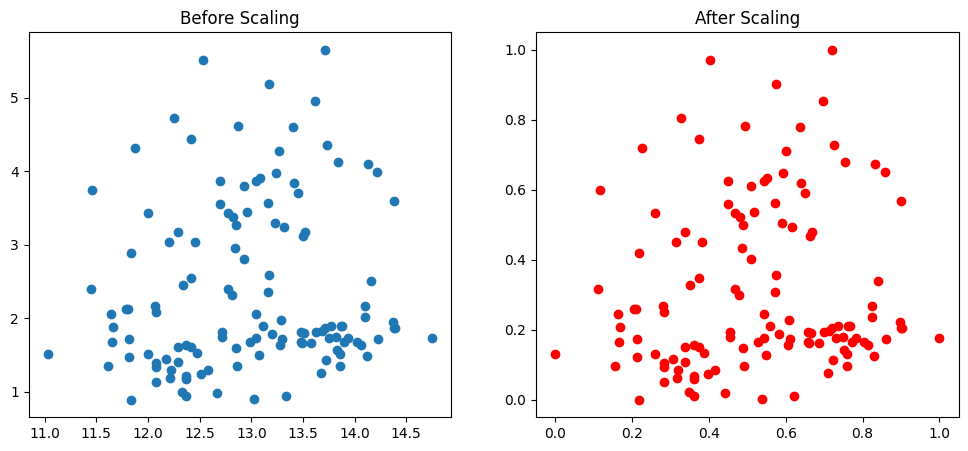

In [32]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.scatter(X_train['Alcohol'],X_train['Malic Acid'])
ax1.set_title('Before Scaling')

ax2.scatter(X_train_scaled['Alcohol'],X_train_scaled['Malic Acid'],color='red')
ax2.set_title('After Scaling')

plt.show()

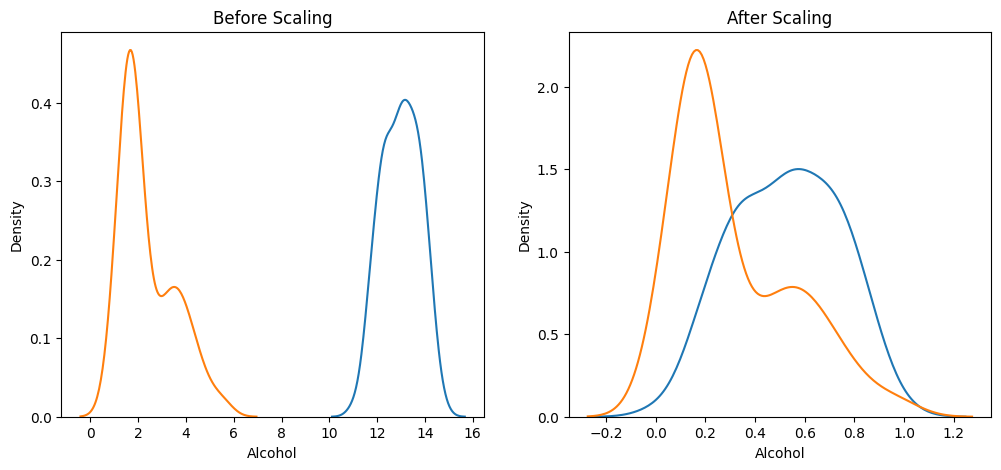

In [35]:
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic Acid'], ax=ax1)

ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax2)

plt.show()


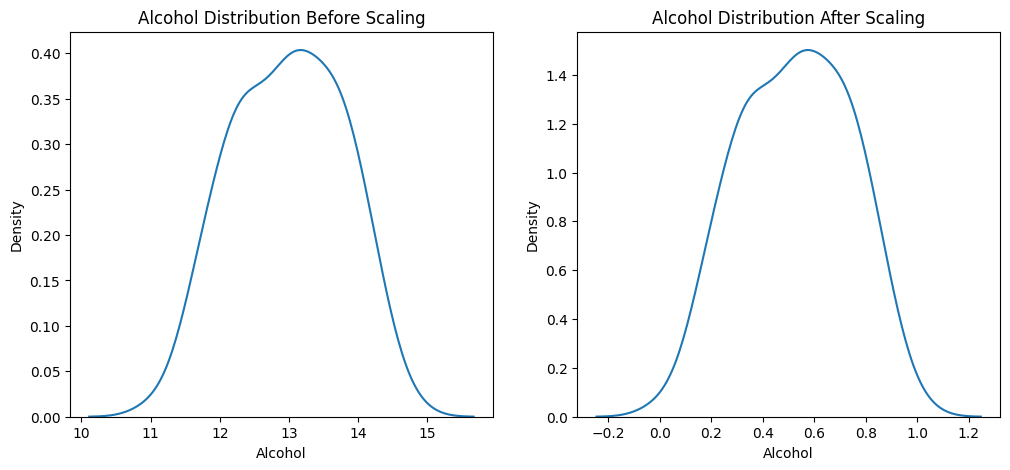

In [36]:
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['Alcohol'], ax=ax1)

ax2.set_title ('Alcohol Distribution After Scaling')
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)

plt.show()


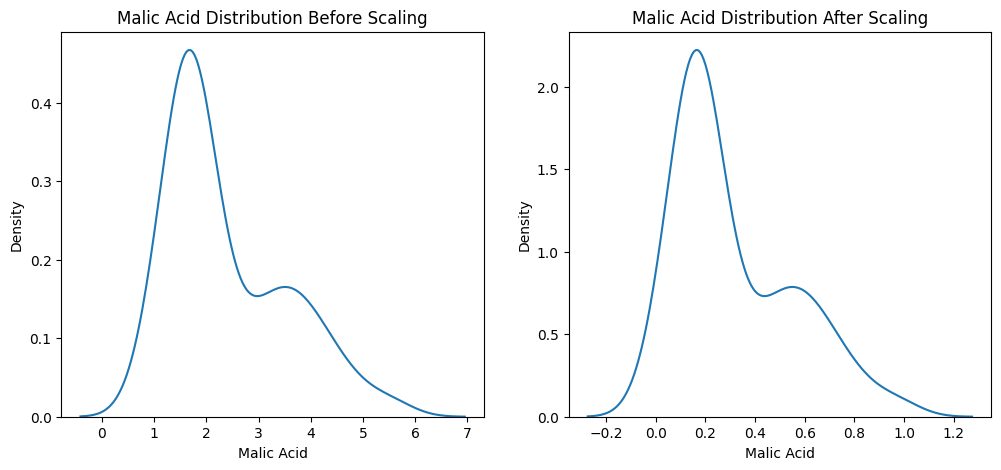

In [37]:
fig, (ax1, ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('Malic Acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic Acid'], ax=ax1)

ax2.set_title('Malic Acid Distribution After Scaling')
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax2)

plt.show()
